# Week 3 Lab: Computer Vision

1. Explore data augmentation and understand its effect on images
2. Build an image classifier using transfer learning (pretrained ResNet18)
3. Run object detection using a pretrained YOLO model

**Dataset:** We use a 3-class subset of CIFAR-10 (airplane, automobile, bird) to keep downloads fast and training quick.

## Setup

In [1]:
# Install ultralytics for Part 3 (YOLO)
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Check for GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Helper function

In [4]:
def show_images(images, titles=None, rows=1):
    """Display a list of PIL images or tensors in a grid."""
    n = len(images)
    cols = int(np.ceil(n / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            if isinstance(img, torch.Tensor):
                img = img.permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
            ax.imshow(img)
            if titles and i < len(titles):
                ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Part 1: Data Augmentation

Data augmentation artificially increases your training set by applying random transformations. This helps prevent overfitting and makes models more robust.

Load a single image and see what different augmentations do to it.

100%|██████████| 170M/170M [11:06<00:00, 256kB/s]


Class: airplane
Original size: (32, 32)


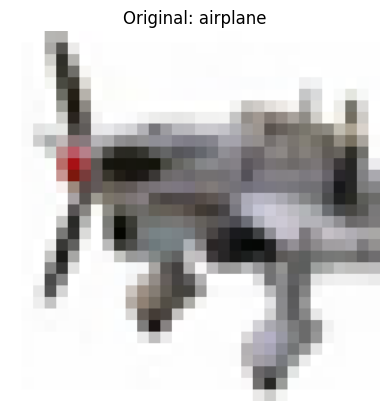

In [5]:
# Download CIFAR-10 and grab one sample image
raw_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
sample_image, sample_label = raw_cifar[49]  # a frog
class_names_all = raw_cifar.classes

# Upscale for better visualization (CIFAR images are 32x32)
sample_image_large = sample_image.resize((224, 224), Image.NEAREST)

print(f'Class: {class_names_all[sample_label]}')
print(f'Original size: {sample_image.size}')
plt.imshow(sample_image_large)
plt.axis('off')
plt.title(f'Original: {class_names_all[sample_label]}')
plt.show()

### 1.1 Geometric Augmentations

These change the spatial layout of the image: flips, rotations, crops.

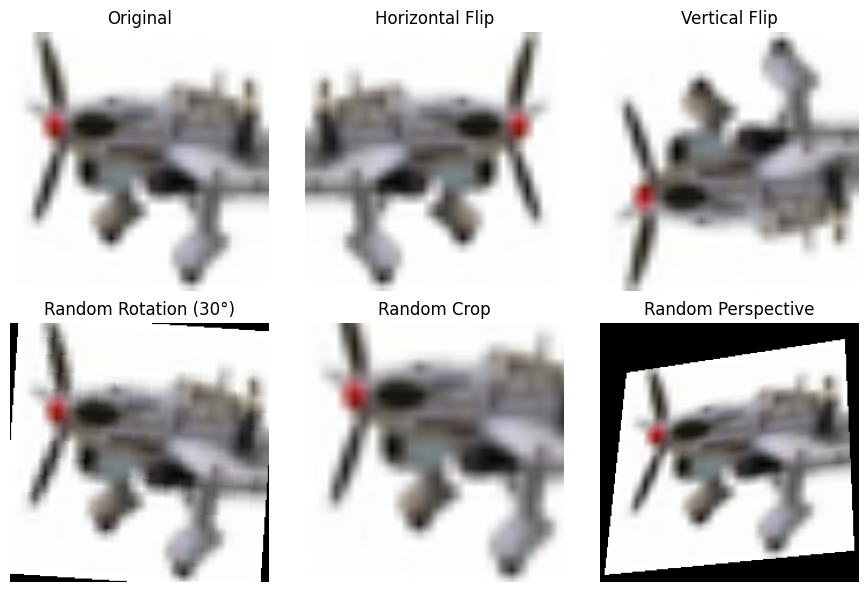

In [6]:
geometric_transforms = {
    'Original': T.Compose([T.Resize(224)]),
    'Horizontal Flip': T.Compose([T.Resize(224), T.RandomHorizontalFlip(p=1.0)]),
    'Vertical Flip': T.Compose([T.Resize(224), T.RandomVerticalFlip(p=1.0)]),
    'Random Rotation (30°)': T.Compose([T.Resize(224), T.RandomRotation(30)]),
    'Random Crop': T.Compose([T.Resize(256), T.RandomCrop(224)]),
    'Random Perspective': T.Compose([T.Resize(224), T.RandomPerspective(distortion_scale=0.4, p=1.0)]),
}

images = [t(sample_image) for t in geometric_transforms.values()]
show_images(images, titles=list(geometric_transforms.keys()), rows=2)

### 1.2 Photometric Augmentations

These change colors, brightness, contrast: simulating different lighting conditions.

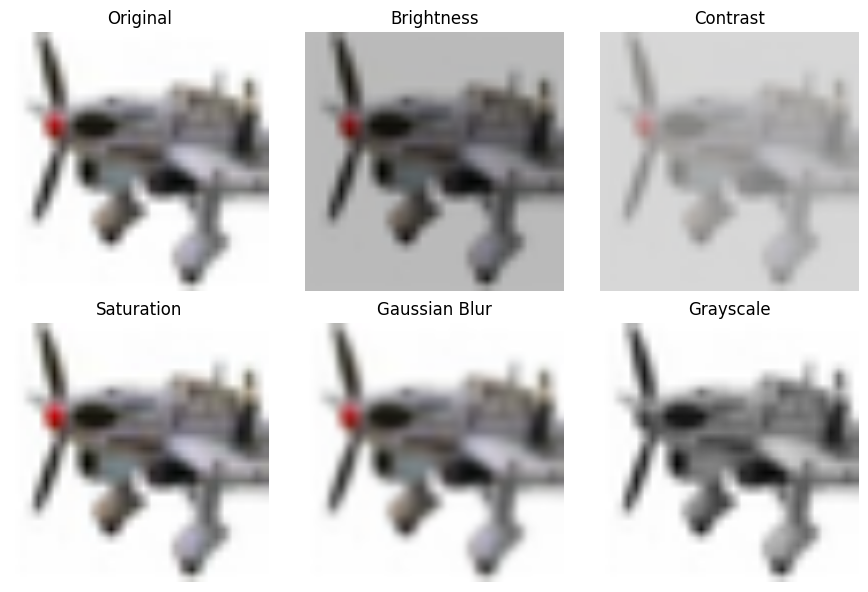

In [7]:
photometric_transforms = {
    'Original': T.Compose([T.Resize(224)]),
    'Brightness': T.Compose([T.Resize(224), T.ColorJitter(brightness=0.8)]),
    'Contrast': T.Compose([T.Resize(224), T.ColorJitter(contrast=0.8)]),
    'Saturation': T.Compose([T.Resize(224), T.ColorJitter(saturation=0.8)]),
    'Gaussian Blur': T.Compose([T.Resize(224), T.GaussianBlur(kernel_size=7)]),
    'Grayscale': T.Compose([T.Resize(224), T.Grayscale(num_output_channels=3)]),
}

images = [t(sample_image) for t in photometric_transforms.values()]
show_images(images, titles=list(photometric_transforms.keys()), rows=2)

### Exercise 1: Build your own augmentation pipeline

Combine at least **3 different augmentations** (mix geometric and photometric) into a single pipeline. Apply it to the sample image **8 times** to see the variety of outputs.

**Hint:** Use `T.Compose([...])` to chain transforms. Remember that `T.RandomHorizontalFlip()` without `p=1.0` will only flip ~50% of the time: that's what you want in a real pipeline.

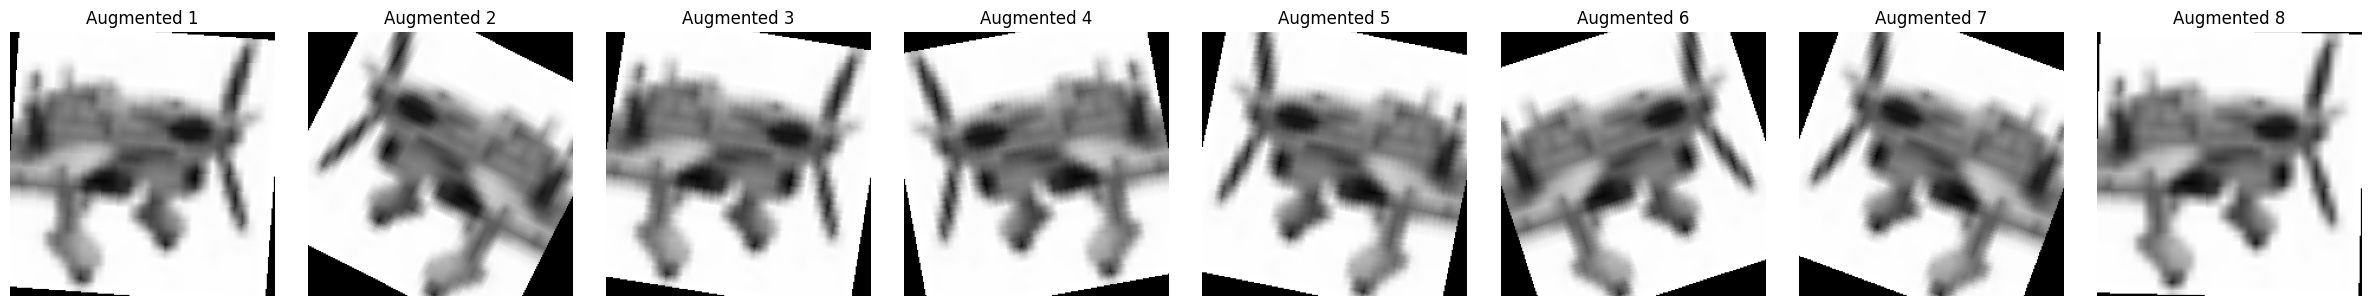

In [23]:
combined_transforms = T.Compose([
            T.Resize(224),
            T.RandomHorizontalFlip(p=0.6),
            T.RandomRotation(30),
            T.Grayscale(num_output_channels=3)])

images = [combined_transforms(sample_image) for _ in range(8)]
show_images(images, titles=[f"Augmented {i+1}" for i in range(8)])

---
## Part 2: Image Classification with Transfer Learning

We'll classify a 3-class subset (to keep training fast) of CIFAR-10: **airplane (0), automobile (1), bird (2)**.

### 2.1 Prepare the dataset

In [9]:
# Classes we'll use (CIFAR-10 indices: airplane=0, automobile=1, bird=2)
SELECTED_CLASSES = [0, 1, 2]
CLASS_NAMES = ['airplane', 'automobile', 'bird']

# Remap labels: original CIFAR label -> 0, 1, 2
LABEL_MAP = {orig: new for new, orig in enumerate(SELECTED_CLASSES)}


def get_subset_indices(dataset, selected_classes):
    """Return indices where the label is in selected_classes."""
    indices = []
    for i, (_, label) in enumerate(dataset):
        if label in selected_classes:
            indices.append(i)
    return indices


class RemappedSubset(torch.utils.data.Dataset):
    """Wraps a Subset and remaps labels to 0..n-1."""
    def __init__(self, dataset, indices, label_map, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, self.label_map[label]


print(f'Selected classes: {CLASS_NAMES}')
print(f'Label mapping: {LABEL_MAP}')

Selected classes: ['airplane', 'automobile', 'bird']
Label mapping: {0: 0, 1: 1, 2: 2}


In [10]:
# Define transforms
# Training: augmentation + normalization
# Validation: just resize + normalization (no augmentation!)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Why normalize with ImageNet stats?
# -> The pretrained model was trained on ImageNet with these exact values.
# Our input must match what the model expects.

train_transform = T.Compose([
    T.Resize(128),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize(128),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [11]:
# Load raw datasets and build subsets
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
raw_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

train_indices = get_subset_indices(raw_train, SELECTED_CLASSES)
test_indices = get_subset_indices(raw_test, SELECTED_CLASSES)

# Subsample training set to 500 per class to keep CPU training fast (~2 min)
SAMPLES_PER_CLASS = 500
train_indices_subsampled = []
for cls in SELECTED_CLASSES:
    cls_indices = [i for i in train_indices if raw_train[i][1] == cls]
    train_indices_subsampled.extend(cls_indices[:SAMPLES_PER_CLASS])

train_dataset = RemappedSubset(raw_train, train_indices_subsampled, LABEL_MAP, transform=train_transform)
val_dataset = RemappedSubset(raw_test, test_indices, LABEL_MAP, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f'Training samples: {len(train_dataset)} ({SAMPLES_PER_CLASS} per class)')
print(f'Validation samples: {len(val_dataset)}')

Training samples: 1500 (500 per class)
Validation samples: 3000


### 2.2 Visualize some training samples

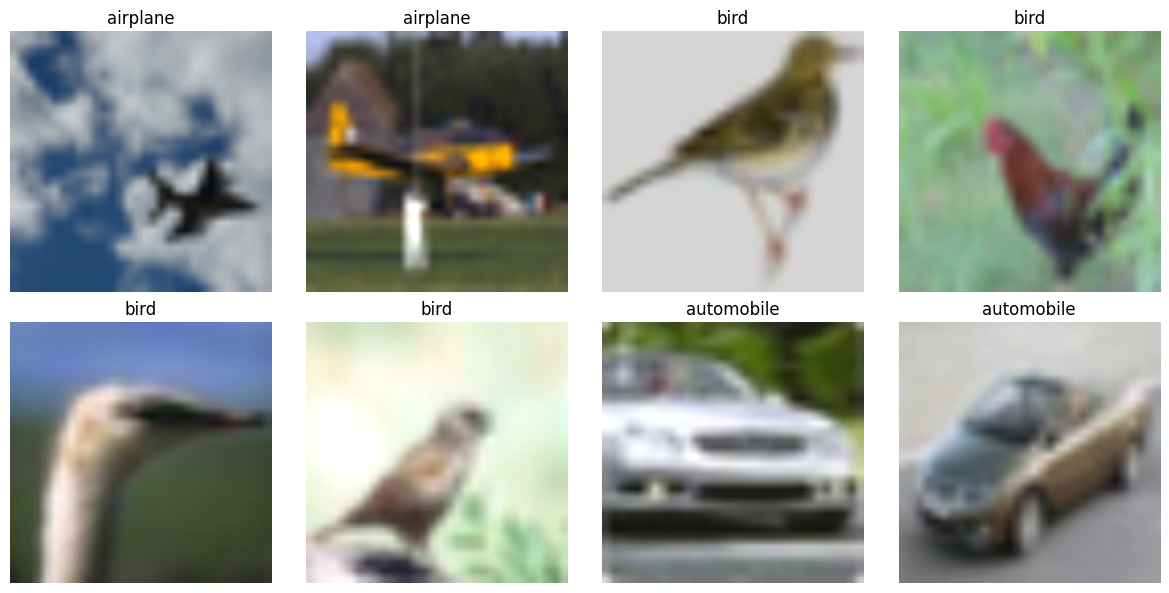

In [12]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    # Reverse ImageNet normalization for visualization
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

# Display a batch
sample_batch, sample_labels = next(iter(train_loader))
sample_imgs = [denormalize(sample_batch[i]) for i in range(8)]
sample_titles = [CLASS_NAMES[sample_labels[i]] for i in range(8)]
show_images(sample_imgs, titles=sample_titles, rows=2)

### 2.3 Build the model

We load a pretrained ResNet18 and replace its final classification layer.

**Key idea:** ResNet18 was trained on ImageNet (1000 classes). We replace the last layer to output 3 classes (our classes). The pretrained layers already know how to extract useful features from images.

### Exercise 2: Modify the classifier head

The pretrained ResNet18's final fully connected layer (`model.fc`) outputs 1000 classes (ImageNet).

1. First, print `model.fc` to see its current shape.
2. Replace `model.fc` with a new `nn.Linear` layer that:
   - Takes the same number of **input features** as the original `model.fc`
   - Outputs the correct number of classes for **our** task

**Hint:** You can get the input features of the original fc layer with `model.fc.in_features`.

In [16]:
# Load pretrained ResNet18
model = models.resnet18(weights='DEFAULT')

# Freeze all pretrained layers (we only want to train the new head)
for param in model.parameters():
    param.requires_grad = False

# --- Your code here ---
# Step 1: Print the current model.fc to see its shape
# Step 2: Replace model.fc with a new nn.Linear(...) layer

print("Before:")
print(model.fc)

print("After:")
num_classes = len(CLASS_NAMES)
model.fc = nn.Linear(model.fc.in_features, num_classes)
print(model.fc)

model = model.to(device)

# Verify: count trainable vs frozen parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')

Before:
Linear(in_features=512, out_features=1000, bias=True)
After:
Linear(in_features=512, out_features=3, bias=True)

Total parameters: 11,178,051
Trainable parameters: 1,539 (0.0%)


### 2.4 Training

### Exercise 3: Complete the training loop

Fill in the missing parts of the training loop below. You need to:
1. Perform the **forward pass** (pass inputs through the model)
2. Compute the **loss** (using the criterion)
3. Perform the **backward pass** (compute gradients)
4. **Update weights** (using the optimizer)

**4-step PyTorch training pattern:**
```
optimizer.zero_grad()     # already provided
outputs = ???             # forward pass
loss = ???                # compute loss
???                       # backward pass
???                       # update weights
```

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

NUM_EPOCHS = 3
train_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # --- Your code here: forward pass, loss, backward, step ---

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    # --- Validation phase ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS}; Loss: {epoch_loss:.4f} - Val Accuracy: {val_acc:.4f}')

print(f'\nFinal validation accuracy: {val_accuracies[-1]:.2%}')

Epoch 1/3; Loss: 0.9203 - Val Accuracy: 0.8303
Epoch 2/3; Loss: 0.4521 - Val Accuracy: 0.8923
Epoch 3/3; Loss: 0.3296 - Val Accuracy: 0.9020

Final validation accuracy: 90.20%


### 2.5 Visualize training progress

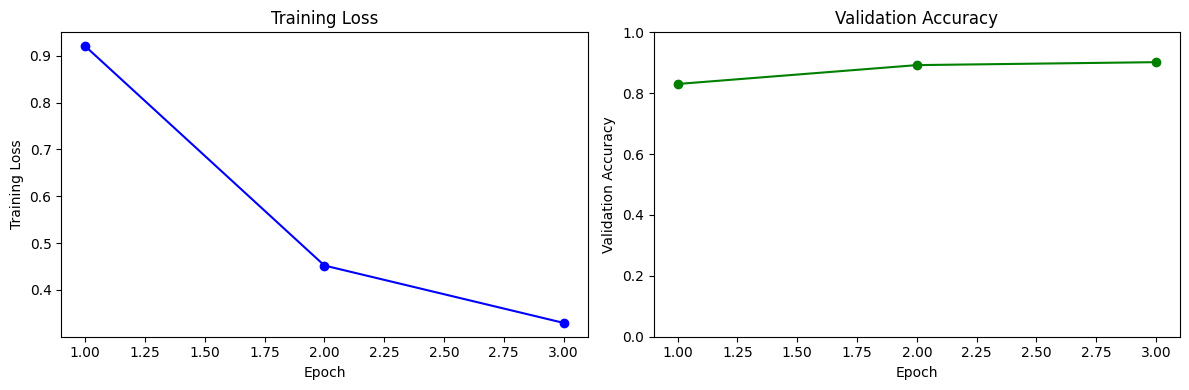

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')

ax2.plot(range(1, NUM_EPOCHS + 1), val_accuracies, 'g-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 2.6: Compute a confusion matrix and per-class metrics

A single accuracy number can be misleading. Compute:
1. A **confusion matrix**: which classes get confused with each other?
2. **Per-class precision and recall**

**Hint:** Use `sklearn.metrics.confusion_matrix` and `sklearn.metrics.classification_report`.

Steps:
- Collect all predictions and true labels from `val_loader` (like the validation loop above)
- Pass them to sklearn functions

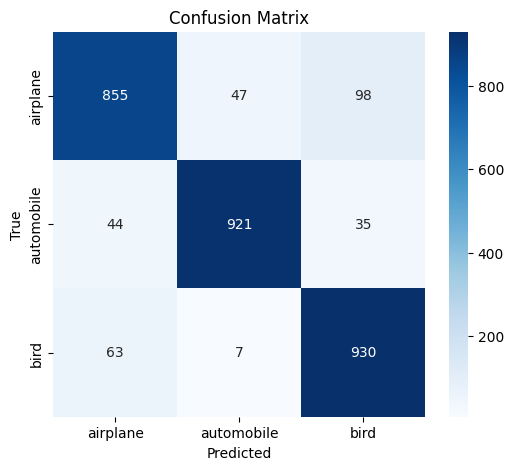

              precision    recall  f1-score   support

    airplane       0.89      0.85      0.87      1000
  automobile       0.94      0.92      0.93      1000
        bird       0.87      0.93      0.90      1000

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect all predictions
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### 2.7 Visualize predictions

Let's look at some actual predictions: especially the wrong ones.

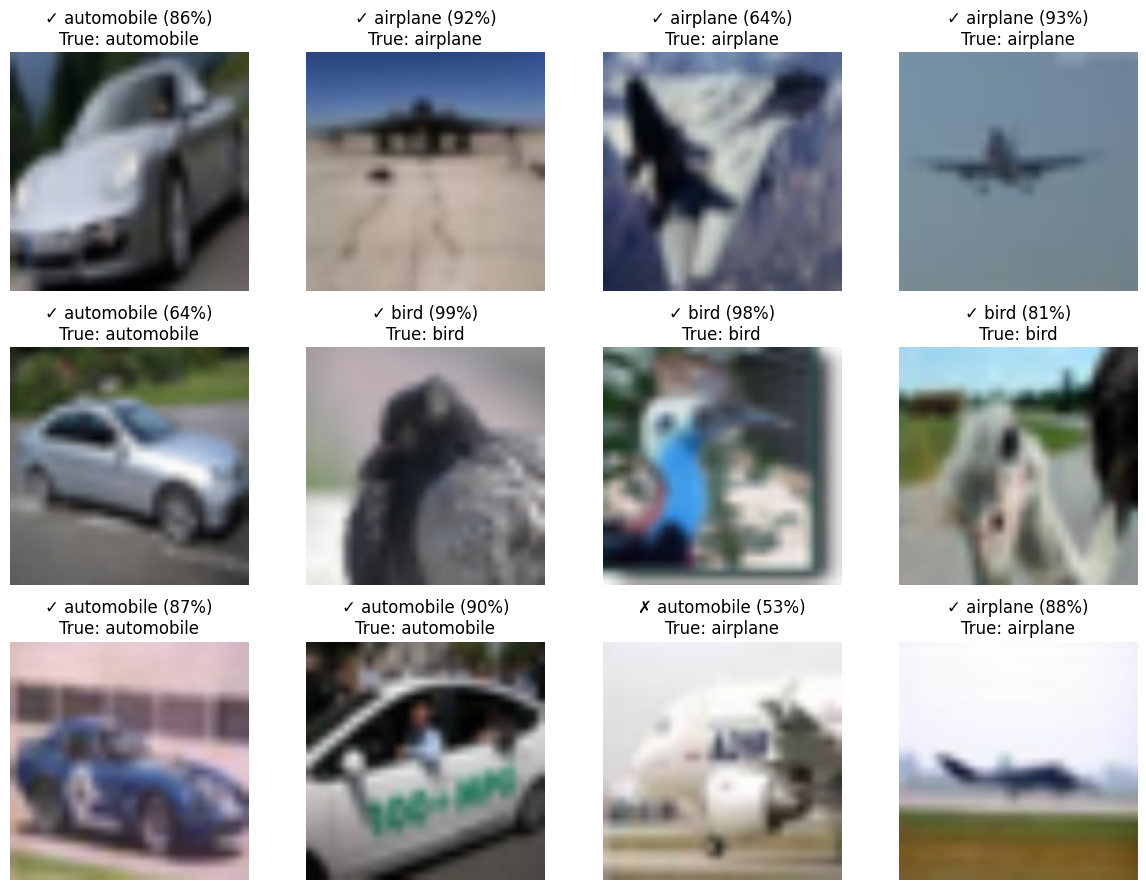

In [26]:
# Show predictions on 12 random validation images
model.eval()
indices = np.random.choice(len(val_dataset), 12, replace=False)
images_to_show = []
titles_to_show = []

for idx in indices:
    img_tensor, true_label = val_dataset[idx]

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(output, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_label].item()

    images_to_show.append(denormalize(img_tensor))
    status = '✓' if pred_label == true_label else '✗'
    titles_to_show.append(f'{status} {CLASS_NAMES[pred_label]} ({confidence:.0%})\nTrue: {CLASS_NAMES[true_label]}')

show_images(images_to_show, titles=titles_to_show, rows=3)

---
## Part 3: Object Detection with YOLO

In classification, we answer "what is this image?" In **object detection**, we answer "what objects are in this image and where?"

We use YOLOv8 (You Only Look Once), a popular real-time detection model. Here we just run a **pretrained** model; no training needed.

In [27]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 nano model (smallest, fastest)
yolo_model = YOLO('yolov8n.pt')
print('YOLOv8 nano model loaded.')
print(f'Number of classes: {len(yolo_model.names)}')
print(f'Some classes: {list(yolo_model.names.values())[:15]}...')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLOv8 nano model loaded.
Number of classes: 80
Some classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird']...


### 3.1 Run detection on CIFAR samples

Let's grab some CIFAR images and see what YOLO finds. Note: CIFAR images are tiny (32×32), YOLO will struggle (resolution matters)!

In [28]:
# Grab a few diverse CIFAR images
# (airplane=0, automobile=1, bird=2, cat=3, dog=5, truck=9)
test_indices_yolo = [10, 1, 30, 42, 15, 99]
test_images_pil = []
test_labels_yolo = []

for idx in test_indices_yolo:
    img, label = raw_cifar[idx]
    # Upscale so YOLO has more to work with
    img_upscaled = img.resize((640, 640), Image.BILINEAR)
    test_images_pil.append(img_upscaled)
    test_labels_yolo.append(class_names_all[label])

print(f'Testing YOLO on {len(test_images_pil)} images')
print(f'True classes: {test_labels_yolo}')

Testing YOLO on 6 images
True classes: ['deer', 'truck', 'airplane', 'bird', 'truck', 'automobile']


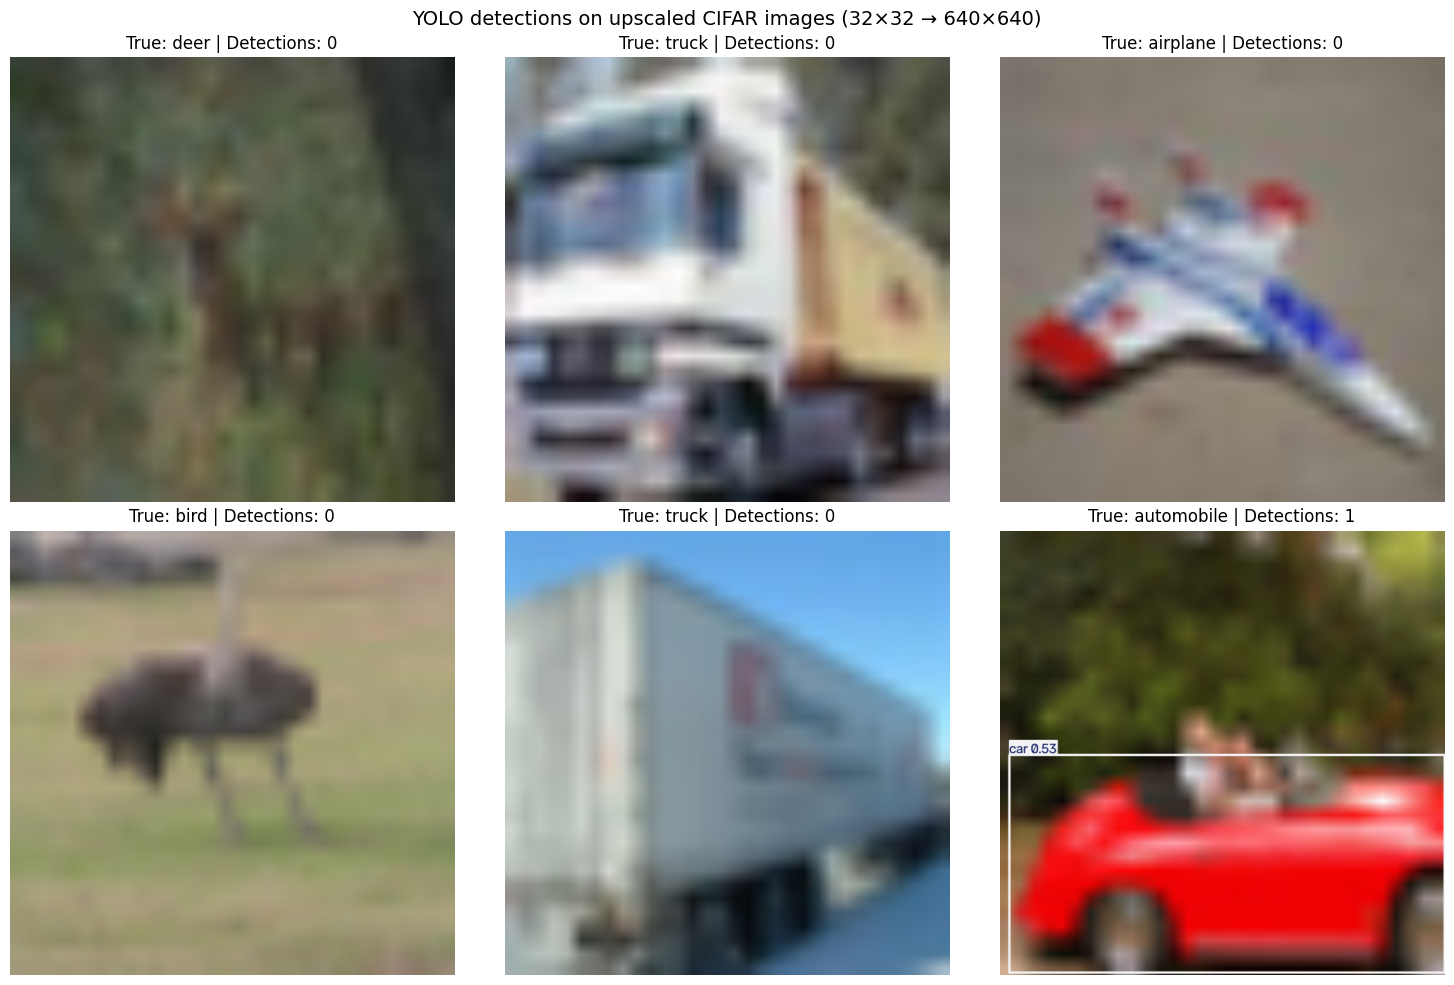

In [29]:
# Run YOLO inference
results = yolo_model(test_images_pil, verbose=False)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (ax, result) in enumerate(zip(axes.flatten(), results)):
    # result.plot() returns BGR numpy array with boxes drawn
    annotated = result.plot()
    ax.imshow(annotated[..., ::-1])  # BGR to RGB

    # Count detections
    n_detections = len(result.boxes)
    ax.set_title(f'True: {test_labels_yolo[i]} | Detections: {n_detections}')
    ax.axis('off')

plt.suptitle('YOLO detections on upscaled CIFAR images (32×32 → 640×640)', fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Inspecting detection results

Each detection has: a bounding box, a class label, and a confidence score.

In [30]:
# Look at the first image's detections in detail
first_result = results[0]

print(f'Image: {test_labels_yolo[0]}')
print(f'Number of detections: {len(first_result.boxes)}')
print()

for box in first_result.boxes:
    cls_id = int(box.cls[0])
    cls_name = yolo_model.names[cls_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    print(f'  {cls_name}: {confidence:.2%} confidence')
    print(f'    Bounding box: ({x1:.0f}, {y1:.0f}) to ({x2:.0f}, {y2:.0f})')

Image: deer
Number of detections: 0



### 3.3 Detection on a more realistic image

CIFAR images are too low-resolution for YOLO to shine. Let's create a synthetic scene or use a built-in sample.

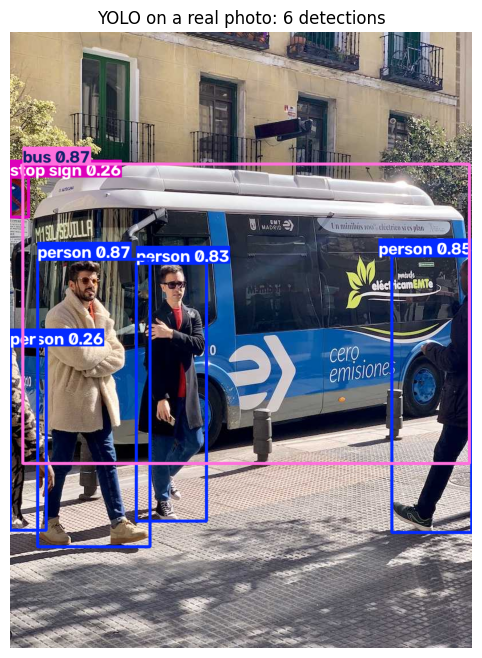


Detections:
  bus: 87.34%
  person: 86.57%
  person: 85.28%
  person: 82.52%
  person: 26.11%
  stop sign: 25.51%


In [31]:
# YOLO ships with sample images - let's use the classic 'bus' image
# This downloads a sample from ultralytics
results_bus = yolo_model('https://ultralytics.com/images/bus.jpg', verbose=False)

plt.figure(figsize=(10, 8))
annotated = results_bus[0].plot()
plt.imshow(annotated[..., ::-1])
plt.title(f'YOLO on a real photo: {len(results_bus[0].boxes)} detections')
plt.axis('off')
plt.show()

print('\nDetections:')
for box in results_bus[0].boxes:
    cls_name = yolo_model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f'  {cls_name}: {conf:.2%}')

### Exercise 4: Confidence threshold experiment

YOLO has a `conf` parameter that sets the minimum confidence for a detection to be kept.

Run detection on the bus image with 4 different confidence thresholds: **0.1, 0.5, 0.8** and display the results side-by-side.

**Hint:** `yolo_model(image_path, conf=0.5, verbose=False)`

What happens to the number and quality of detections as you increase the threshold?

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


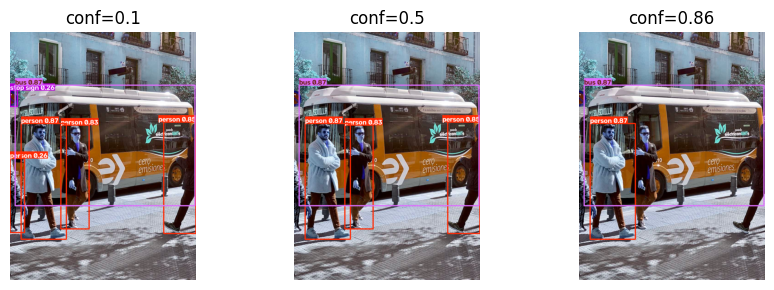

In [37]:
thresholds = [0.1, 0.5, 0.86]
image_url = 'https://ultralytics.com/images/bus.jpg'

images = [yolo_model(image_url, conf=t, verbose=False)[0].plot() for t in thresholds]
show_images(images, titles=[f"conf={t}" for t in thresholds])











### Bonus: Try it on your own image

Upload a photo and run YOLO on it.

Found https://images.trvl-media.com/place/6350699/f8ae2db6-94cc-4898-aa46-e275588c3787.jpg locally at f8ae2db6-94cc-4898-aa46-e275588c3787.jpg


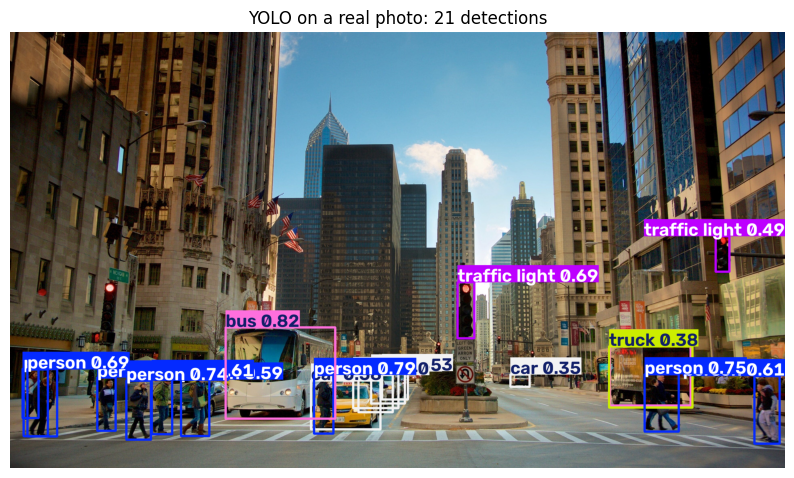


Detections:
  bus: 82.38%
  person: 78.79%
  person: 74.75%
  person: 74.44%
  person: 68.93%
  traffic light: 68.88%
  person: 61.09%
  person: 60.79%
  person: 59.14%
  car: 57.67%
  person: 56.49%
  traffic light: 49.14%
  person: 43.02%
  car: 40.44%
  truck: 38.21%
  car: 37.95%
  bus: 37.38%
  car: 34.92%
  car: 34.85%
  person: 34.68%
  car: 33.05%


In [34]:
# Option A: Upload a file (Colab)
# from google.colab import files
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]

# Option B: Use a URL
image_path = 'https://images.trvl-media.com/place/6350699/f8ae2db6-94cc-4898-aa46-e275588c3787.jpg'


results = yolo_model(image_path, verbose=False)

plt.figure(figsize=(10, 8))
annotated = results[0].plot()
plt.imshow(annotated[..., ::-1])
plt.title(f'YOLO on a real photo: {len(results_bus[0].boxes)} detections')
plt.axis('off')
plt.show()

print('\nDetections:')
for box in results[0].boxes:
    cls_name = yolo_model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f'  {cls_name}: {conf:.2%}')

